https://www.data.go.kr/data/15099446/fileData.do   

> 해당 데이터셋을 활용하여 20-1 ~ 22-12 의 기간동안 확진자 수와 사망자 수 plot

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

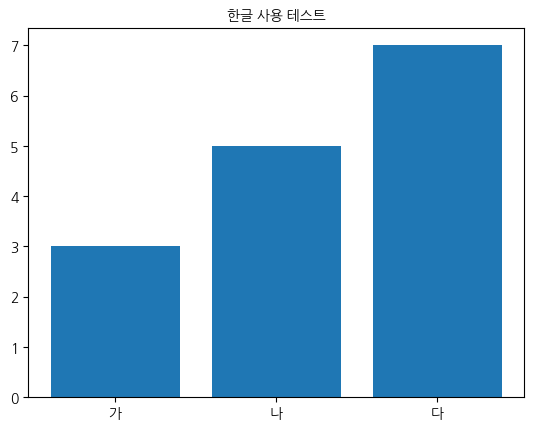

In [33]:
import matplotlib.font_manager as fm

# 폰트 설정
font_path = "/System/Library/AssetsV2/com_apple_MobileAsset_Font7/bad9b4bf17cf1669dde54184ba4431c22dcad27b.asset/AssetData/NanumGothic.ttc"
font_prop = fm.FontProperties(fname=font_path)

# Matplotlib 설정
plt.rcParams["font.family"] = font_prop.get_name()  # Nanum Gothic 적용
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 데이터 설정
dat = pd.Series({'가': 3, '나': 5, '다': 7})

# 그래프 그리기
plt.bar(dat.index, dat)

# X축 한글 적용
plt.xticks(fontproperties=font_prop)
plt.title("한글 사용 테스트", fontproperties=font_prop)

plt.show()

In [34]:
df_covid = pd.read_csv('/Users/kimdohyeon/건양대학교병원_바이오헬스/Biomedical_AI_Train/ML/covid19_DJ.csv', encoding='euc-kr')
df_covid

,연번,시도,시군구,연,월,확진자,사망자,데이터기준일자
0,1,대전광역시,유성구,2020,1,1,0,2022-03-17
1,2,대전광역시,유성구,2020,2,7,0,2022-03-17
2,3,대전광역시,유성구,2020,3,21,0,2022-03-17
3,4,대전광역시,유성구,2020,4,4,0,2022-03-17
4,5,대전광역시,유성구,2020,5,5,0,2022-03-17
5,6,대전광역시,유성구,2020,6,18,0,2022-03-17
6,7,대전광역시,유성구,2020,7,15,0,2022-03-17
7,8,대전광역시,유성구,2020,8,29,0,2022-03-17
8,9,대전광역시,유성구,2020,9,15,0,2022-03-17
9,10,대전광역시,유성구,2020,10,43,1,2022-03-17


In [35]:
df_covid.columns

Index(['연번', '시도', '시군구', '연', '월', '확진자', '사망자', '데이터기준일자'], dtype='object')

In [36]:
len(df_covid.columns)

8

In [37]:
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   연번       36 non-null     int64 
 1   시도       36 non-null     object
 2   시군구      36 non-null     object
 3   연        36 non-null     int64 
 4   월        36 non-null     int64 
 5   확진자      36 non-null     int64 
 6   사망자      36 non-null     int64 
 7   데이터기준일자  36 non-null     object
dtypes: int64(5), object(3)
memory usage: 2.4+ KB


In [38]:
len(df_covid)

36

### 확진자가 가장 많이 나온 월을 구하기

how   
-> 확진자를 내림차순으로 정렬하고 ``head()`` 메소드를 통해 상위 행 확인   
-> 또는 ``max()`` 메소드를 통해 확진자가 가장 많이 나온 행 확인   
-> 이후 행의 연번을 확인하고 '연', '월'을 출력

In [39]:
covid_per_day = df_covid['확진자']
covid_per_day.sort_values(ascending=False)
covid_per_day[covid_per_day == covid_per_day.max()]

26    72801
Name: 확진자, dtype: int64

In [40]:
df_covid.loc[26, ['연', '월']]

연    2022
월       3
Name: 26, dtype: object

In [42]:
df_covid.columns

Index(['연번', '시도', '시군구', '연', '월', '확진자', '사망자', '데이터기준일자'], dtype='object')

2022년 3월에 코로나 확진자가 가장 많이 나옴을 확인할 수 있다.

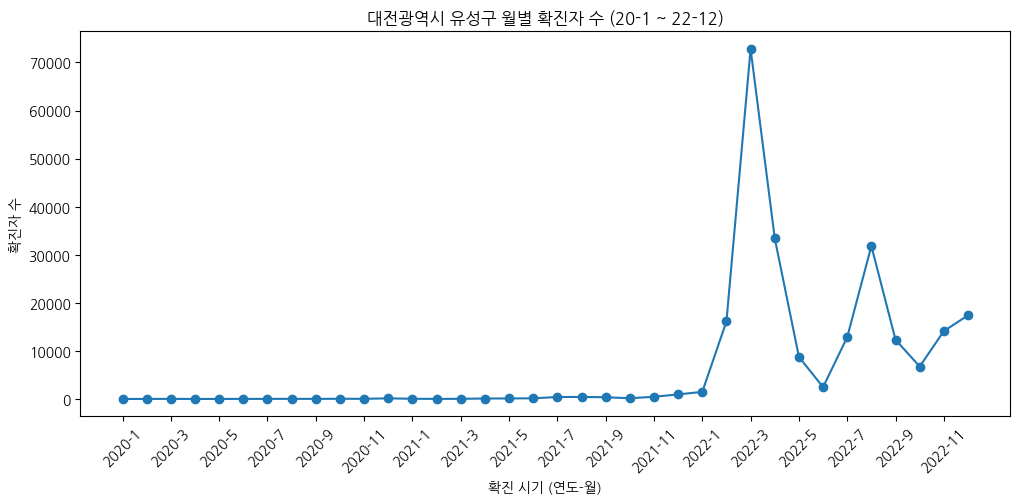

In [51]:
df_covid['연-월'] = df_covid['연'].astype(str) + '-' + df_covid['월'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(df_covid['연-월'], covid_per_day, marker='o')

plt.xticks(df_covid['연-월'].iloc[::2], rotation=45, fontsize=10)
plt.title('대전광역시 유성구 월별 확진자 수 (20-1 ~ 22-12)')
plt.xlabel('확진 시기 (연도-월)')
plt.ylabel('확진자 수')

plt.show()

### 사망자 수를 막대그래프로 시각화하기   
가장 많은 사망자가 나온 달의 막대그래프 = red, 이외의 달 = gray

In [57]:
covid_per_death = df_covid['사망자']
max_death = covid_per_death.max()
max_death_index = covid_per_death.idxmax()

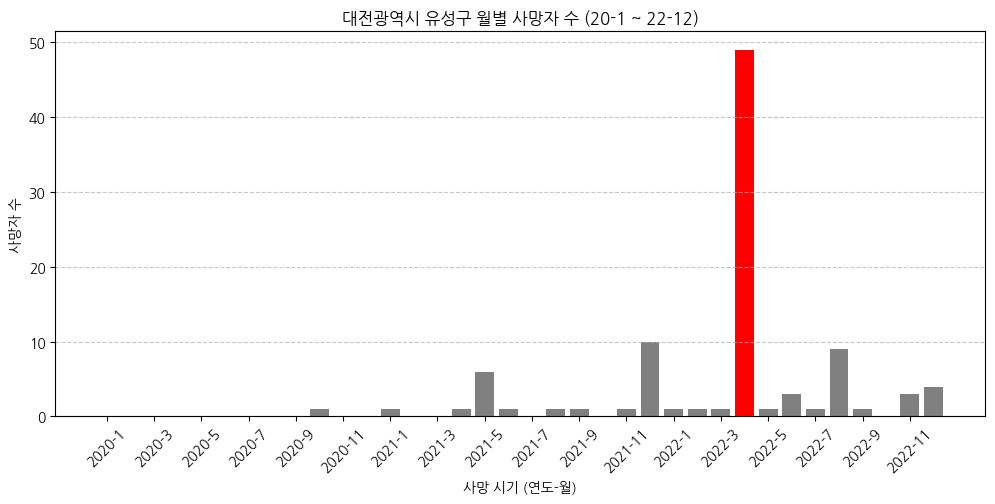

In [ ]:
plt.figure(figsize=(12, 5))

colors = ['red' if x == max_death_index else 'gray' for x in range(len(covid_per_death))]

plt.bar(df_covid['연-월'], covid_per_death, color=colors)
plt.xticks(df_covid['연-월'].iloc[::2], rotation=45, fontsize=10)

plt.title('대전광역시 유성구 월별 사망자 수 (20-1 ~ 22-12)')
plt.xlabel('사망 시기 (연도-월)')
plt.ylabel('사망자 수')

plt.grid(axis='y', linestyle='--', alpha=0.7)

# 그래프 출력
plt.show()